In [7]:
import os, json, datetime
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import squidpy as sq

import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------
# Fixed inputs (do not overwrite)
# ----------------------------
ADATA_PATH = "combined_1103_with_cell_type.h5ad"

# Use ONLY cell_type everywhere (per your request)
CLUSTER_KEY = "cell_type"
SAMPLE_KEY  = "sample_name"
TIME_KEY    = "Timepoint"   # already T0/T2
RESP_KEY    = "Response"    # already Responder/Non-responder

# Squidpy settings (exactly as your method text)
COORD_TYPE = "generic"
N_PERMS = 10_000

# Output root (unique folder every run)
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUTROOT = Path(f"outputs_nhood_{ts}")
(OUTROOT / "00_meta").mkdir(parents=True, exist_ok=False)
(OUTROOT / "01_by_sample").mkdir(parents=True, exist_ok=False)
(OUTROOT / "02_by_group").mkdir(parents=True, exist_ok=False)
(OUTROOT / "03_plots").mkdir(parents=True, exist_ok=False)
(OUTROOT / "04_pair_boxplots").mkdir(parents=True, exist_ok=False)

run_cfg = {
    "ADATA_PATH": ADATA_PATH,
    "CLUSTER_KEY": CLUSTER_KEY,
    "SAMPLE_KEY": SAMPLE_KEY,
    "TIME_KEY": TIME_KEY,
    "RESP_KEY": RESP_KEY,
    "COORD_TYPE": COORD_TYPE,
    "N_PERMS": N_PERMS,
}
with open(OUTROOT / "00_meta" / "run_config.json", "w") as f:
    json.dump(run_cfg, f, indent=2)

print("OUTROOT =", OUTROOT)



/work/users/k/y/kyutae/stlearn/stlearn_env/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


OUTROOT = outputs_nhood_20260311_180733


In [8]:
adata = sc.read_h5ad(ADATA_PATH)

need_obs = [CLUSTER_KEY, SAMPLE_KEY, TIME_KEY, RESP_KEY]
missing = [c for c in need_obs if c not in adata.obs.columns]
if missing:
    raise KeyError(f"Missing obs columns: {missing}")

if "spatial" not in adata.obsm.keys():
    raise KeyError("adata.obsm['spatial'] is required for coord_type='generic'.")

print("Timepoint counts:\n", adata.obs[TIME_KEY].value_counts(dropna=False))
print("\nResponse counts:\n", adata.obs[RESP_KEY].value_counts(dropna=False))
print("\ncell_type top:\n", adata.obs[CLUSTER_KEY].value_counts().head(10))
print("\n#samples:", adata.obs[SAMPLE_KEY].nunique())



Timepoint counts:
 Timepoint
T0    698040
T2    607762
Name: count, dtype: int64

Response counts:
 Response
Responder        780703
Non-responder    525099
Name: count, dtype: int64

cell_type top:
 cell_type
Cancer cell                           478358
C1QC-TAM                              175290
Fibroblast                            148951
Exhausted T cell(tEx)                  99985
Endothelial                            78592
Plasma cell                            52663
B cell                                 45236
Intermediate exhausted T cell(iEx)     41625
Naive T cell                           40852
Proliferative T cell                   27732
Name: count, dtype: int64

#samples: 57


In [9]:
def _safe_to_csv(df: pd.DataFrame, path: Path):
    df.to_csv(path, index=True)

samples = adata.obs[SAMPLE_KEY].astype(str).unique().tolist()
samples.sort()

for s in samples:
    ad_s = adata[adata.obs[SAMPLE_KEY].astype(str) == s].copy()
    # Build neighbor graph (as in your methods)
    sq.gr.spatial_neighbors(ad_s, coord_type=COORD_TYPE)

    # Neighborhood enrichment (n_perms=10,000)
    sq.gr.nhood_enrichment(ad_s, cluster_key=CLUSTER_KEY, n_perms=N_PERMS)

    # Save z-score matrix
    z = ad_s.uns[f"{CLUSTER_KEY}_nhood_enrichment"]["zscore"]
    cats = ad_s.obs[CLUSTER_KEY].astype("category").cat.categories.astype(str)

    z_df = pd.DataFrame(z, index=cats, columns=cats)
    _safe_to_csv(z_df, OUTROOT / "01_by_sample" / f"{s}__zscore.csv")

print("Done: by-sample enrichment saved to", OUTROOT / "01_by_sample")


  0%|          | 0/10000 [00:00<?, ?/s]

  0%|          | 0/10000 [00:00<?, ?/s]

  0%|          | 0/10000 [00:00<?, ?/s]

  0%|          | 0/10000 [00:00<?, ?/s]

  0%|          | 0/10000 [00:00<?, ?/s]

...

  0%|          | 0/10000 [00:00<?, ?/s]

  0%|          | 0/10000 [00:00<?, ?/s]

  0%|          | 0/10000 [00:00<?, ?/s]

  0%|          | 0/10000 [00:00<?, ?/s]

Done: by-sample enrichment saved to outputs_nhood_20260311_180733/01_by_sample


In [10]:
def group_label(row):
    tp = str(row[TIME_KEY])
    rp = str(row[RESP_KEY])
    if tp not in {"T0", "T2"}:
        return None
    if rp not in {"Responder", "Non-responder"}:
        return None
    return f"{tp}_{'R' if rp=='Responder' else 'NR'}"

meta = adata.obs[[SAMPLE_KEY, TIME_KEY, RESP_KEY]].copy()
meta[SAMPLE_KEY] = meta[SAMPLE_KEY].astype(str)
meta["group"] = meta.apply(group_label, axis=1)

# sample -> group (each sample should belong to 1 group)
sample_to_group = meta.drop_duplicates(subset=[SAMPLE_KEY])[ [SAMPLE_KEY, "group"] ]
sample_to_group = sample_to_group.dropna()

groups = ["T0_R", "T0_NR", "T2_R", "T2_NR"]
print(sample_to_group["group"].value_counts())


group
T0_R     18
T2_R     17
T0_NR    13
T2_NR     9
Name: count, dtype: int64


In [11]:
def load_z(sample_name: str) -> pd.DataFrame:
    p = OUTROOT / "01_by_sample" / f"{sample_name}__zscore.csv"
    return pd.read_csv(p, index_col=0)

# Load all sample matrices, keep consistent order by reindexing
sample_mats = {}
all_labels = None

for s in sample_to_group[SAMPLE_KEY].tolist():
    df = load_z(s)
    if all_labels is None:
        all_labels = df.index.astype(str)
    df = df.reindex(index=all_labels, columns=all_labels)
    sample_mats[s] = df

group_means = {}
for g in groups:
    s_list = sample_to_group.loc[sample_to_group["group"] == g, SAMPLE_KEY].tolist()
    if len(s_list) == 0:
        print("WARNING: empty group", g)
        continue
    stack = np.stack([sample_mats[s].to_numpy(dtype=float) for s in s_list], axis=0)
    mean_mat = np.nanmean(stack, axis=0)
    gm = pd.DataFrame(mean_mat, index=all_labels, columns=all_labels)
    group_means[g] = gm
    gm.to_csv(OUTROOT / "02_by_group" / f"group_mean__{g}.csv")

print("Done: group means saved to", OUTROOT / "02_by_group")


Done: group means saved to outputs_nhood_20260311_180733/02_by_group


In [12]:
def savefig_multi(fig, outbase: Path):
    fig.savefig(str(outbase) + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(str(outbase) + ".pdf", bbox_inches="tight")
    plt.close(fig)

# shared global scale across 4 heatmaps
vals = []
for g, df in group_means.items():
    vals.append(df.to_numpy(dtype=float).ravel())
vals = np.concatenate(vals)
v = np.nanmax(np.abs(vals))
if not np.isfinite(v) or v == 0:
    v = 1.0

fig, axes = plt.subplots(2, 2, figsize=(18, 16))
axes = axes.ravel()

for ax, g in zip(axes, ["T0_R","T0_NR","T2_R","T2_NR"]):
    df = group_means.get(g)
    if df is None:
        ax.axis("off")
        ax.set_title(f"{g} (missing)")
        continue
    sns.heatmap(df, ax=ax, cmap="RdBu_r", vmin=-v, vmax=v, center=0, square=True,
                cbar=True)
    ax.set_title(g)
    ax.set_xlabel("")
    ax.set_ylabel("")

savefig_multi(fig, OUTROOT / "03_plots" / "heatmap_group_means")
print("Saved heatmap_group_means to", OUTROOT / "03_plots")


Saved heatmap_group_means to outputs_nhood_20260311_180733/03_plots


In [13]:
def align(A: pd.DataFrame, B: pd.DataFrame):
    idx = A.index.intersection(B.index)
    col = A.columns.intersection(B.columns)
    return A.loc[idx, col], B.loc[idx, col]

def delta(A: pd.DataFrame, B: pd.DataFrame) -> pd.DataFrame:
    A2, B2 = align(A, B)
    return A2 - B2

# Δ(R-NR) at T0 and T2
d_T0 = delta(group_means["T0_R"], group_means["T0_NR"])
d_T2 = delta(group_means["T2_R"], group_means["T2_NR"])

# ΔΔ = (T2_R - T2_NR) - (T0_R - T0_NR)
d_DiD = delta(d_T2, d_T0)

d_T0.to_csv(OUTROOT / "03_plots" / "delta_RminusNR_T0.csv")
d_T2.to_csv(OUTROOT / "03_plots" / "delta_RminusNR_T2.csv")
d_DiD.to_csv(OUTROOT / "03_plots" / "delta_DiD.csv")

# plot with shared scale per matrix (as you did)
def plot_delta(df: pd.DataFrame, title: str, outname: str):
    vals = df.to_numpy(dtype=float).ravel()
    v = np.nanmax(np.abs(vals))
    if not np.isfinite(v) or v == 0:
        v = 1.0
    fig = plt.figure(figsize=(10, 8))
    ax = plt.gca()
    sns.heatmap(df, ax=ax, cmap="RdBu_r", vmin=-v, vmax=v, center=0, square=True, cbar=True)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    savefig_multi(fig, OUTROOT / "03_plots" / outname)

plot_delta(d_T0, "Δ (Responder - Non-responder) at T0", "heatmap_delta_RminusNR_T0")
plot_delta(d_T2, "Δ (Responder - Non-responder) at T2", "heatmap_delta_RminusNR_T2")
plot_delta(d_DiD, "ΔΔ (Difference-in-differences)", "heatmap_delta_DiD")

print("Saved delta matrices + heatmaps to", OUTROOT / "03_plots")


Saved delta matrices + heatmaps to outputs_nhood_20260311_180733/03_plots


In [14]:
from scipy.stats import ranksums
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# REQUIRED order (per your request)
ORDER = ["T0_NR", "T0_R", "T2_NR", "T2_R"]

# Fixed color mapping (prevents color drift across runs)
# If you want different exact colors, change ONLY these 4.
PALETTE = {
    "T0_NR": "#9E9E9E",  # gray
    "T0_R":  "#4C72B0",  # blue
    "T2_NR": "#BDBDBD",  # light gray
    "T2_R":  "#55A868",  # green
}

def savefig_multi(fig, outbase):
    fig.savefig(str(outbase) + ".png", dpi=300, bbox_inches="tight")
    fig.savefig(str(outbase) + ".pdf", bbox_inches="tight")
    plt.close(fig)

def p_to_stars(p):
    if not np.isfinite(p):
        return "n/a"
    if p < 1e-4:
        return "****"
    if p < 1e-3:
        return "***"
    if p < 1e-2:
        return "**"
    if p < 5e-2:
        return "*"
    return "ns"

def add_bracket(ax, x1, x2, y, h, text, lw=1.5):
    """
    x1, x2: category positions (ints)
    y: baseline y
    h: bracket height
    """
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c="black")
    ax.text((x1 + x2) * 0.5, y + h, text, ha="center", va="bottom")

def get_sample_value(sample_df: pd.DataFrame, A: str, B: str):
    if A not in sample_df.index or B not in sample_df.columns:
        return np.nan
    return float(sample_df.loc[A, B])

# TODO: Put ONLY pairs you actually used before (do not add new analyses).
PAIRS = [("C1QC-TAM","Exhausted T cell(tEx)")]  # e.g., [("C1QC-TAM","Exhausted T cell(tEx)"), ("Fibroblast","Endothelial")]

rows = [('T0_NR','T0_R','T2_NR','T2_R')]

for A, B in PAIRS:
    # collect sample-level values
    data = []
    for s, g in sample_to_group[[SAMPLE_KEY, "group"]].itertuples(index=False):
        zdf = sample_mats[s]
        val = get_sample_value(zdf, A, B)
        data.append((s, g, val))
    dfp = pd.DataFrame(data, columns=["sample", "group", "zscore"]).dropna()

    # enforce group order & drop other groups if any
    dfp = dfp[dfp["group"].isin(ORDER)].copy()

    # stats (ONLY what you already did: R vs NR within each timepoint)
    # x-axis positions: 0=T0_NR, 1=T0_R, 2=T2_NR, 3=T2_R
    comp_specs = [
        ("T0: R vs NR", "T0_NR", "T0_R", 0, 1),
        ("T2: R vs NR", "T2_NR", "T2_R", 2, 3),
    ]

    pvals = {}
    for contrast, g1, g2, _, _ in comp_specs:
        x = dfp.loc[dfp["group"] == g2, "zscore"].to_numpy()  # R
        y = dfp.loc[dfp["group"] == g1, "zscore"].to_numpy()  # NR
        if len(x) > 0 and len(y) > 0:
            p = ranksums(x, y).pvalue
        else:
            p = np.nan
        pvals[contrast] = (p, len(x), len(y))

    # plot
    fig = plt.figure(figsize=(8.5, 5.5))
    ax = plt.gca()

    sns.boxplot(
        data=dfp, x="group", y="zscore",
        order=ORDER, palette=PALETTE, ax=ax
    )
    sns.stripplot(
        data=dfp, x="group", y="zscore",
        order=ORDER, ax=ax,
        size=3, jitter=0.25, color="black", alpha=0.6
    )

    ax.set_title(f"{A} vs {B} (nhood enrichment z-score)")
    ax.set_xlabel("")
    ax.set_ylabel("z-score")

    # add brackets
    y_max = np.nanmax(dfp["zscore"].to_numpy()) if len(dfp) else 0.0
    y_min = np.nanmin(dfp["zscore"].to_numpy()) if len(dfp) else 0.0
    y_range = max(1e-6, y_max - y_min)

    base = y_max + 0.08 * y_range
    step = 0.10 * y_range
    h = 0.03 * y_range

    for i, (contrast, g1, g2, x1, x2) in enumerate(comp_specs):
        p, nR, nNR = pvals[contrast]
        txt = f"p={p:.2e} ({p_to_stars(p)})" if np.isfinite(p) else "p=n/a"
        add_bracket(ax, x1, x2, base + i * step, h, txt)

        rows.append({
            "A": A, "B": B, "contrast": contrast,
            "pvalue": p, "n_R": nR, "n_NR": nNR
        })

    outbase = OUTROOT / "04_pair_boxplots" / f"{A}__{B}__boxplot"
    savefig_multi(fig, outbase)

stats = pd.DataFrame(rows)
stats.to_csv(OUTROOT / "04_pair_boxplots" / "pair_stats.csv", index=False)

print("Saved pair boxplots + bracket p-values to", OUTROOT / "04_pair_boxplots")



/tmp/kyutae/35672519/c1516ood14.ll.unc.edu/ipykernel_1384235/2258443851.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Saved pair boxplots + bracket p-values to outputs_nhood_20260311_180733/04_pair_boxplots


OUTDIR = outputs_distance_sig_prevstyle_20260219_203134
pEx genes used: 14/14
tEx genes used: 66/66
[OK] saved df: outputs_distance_sig_prevstyle_20260219_203134/df_tex_prevstyle_distance_signatures.csv


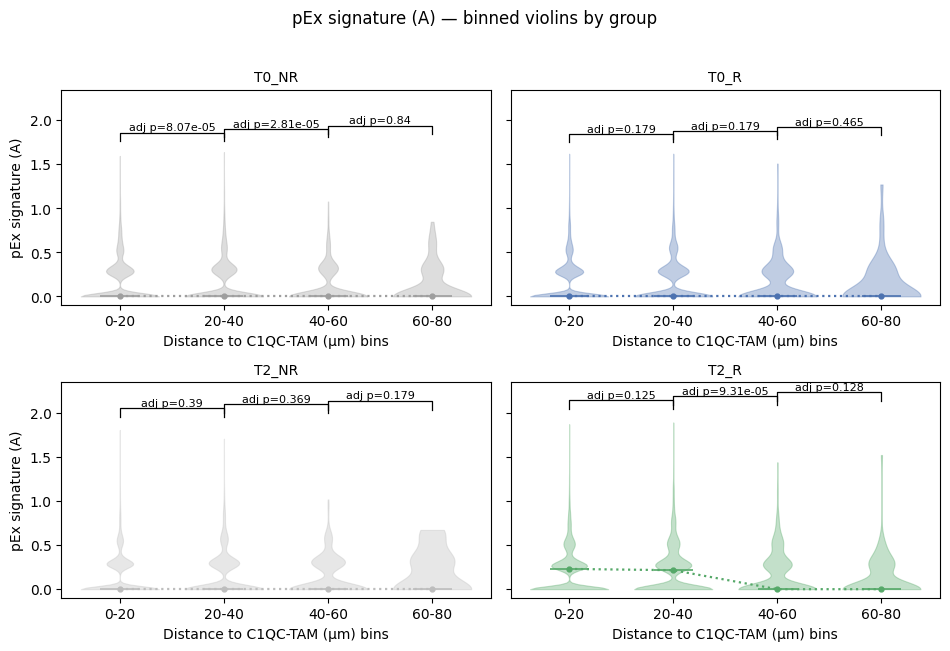

[OK] saved: outputs_distance_sig_prevstyle_20260219_203134/pEx_signature_(A)_binned_violin_by_group_prevstyle.png
[OK] stats saved: outputs_distance_sig_prevstyle_20260219_203134/pEx_signature_(A)_binned_violin_by_group_prevstyle_pairwise_wilcox.csv


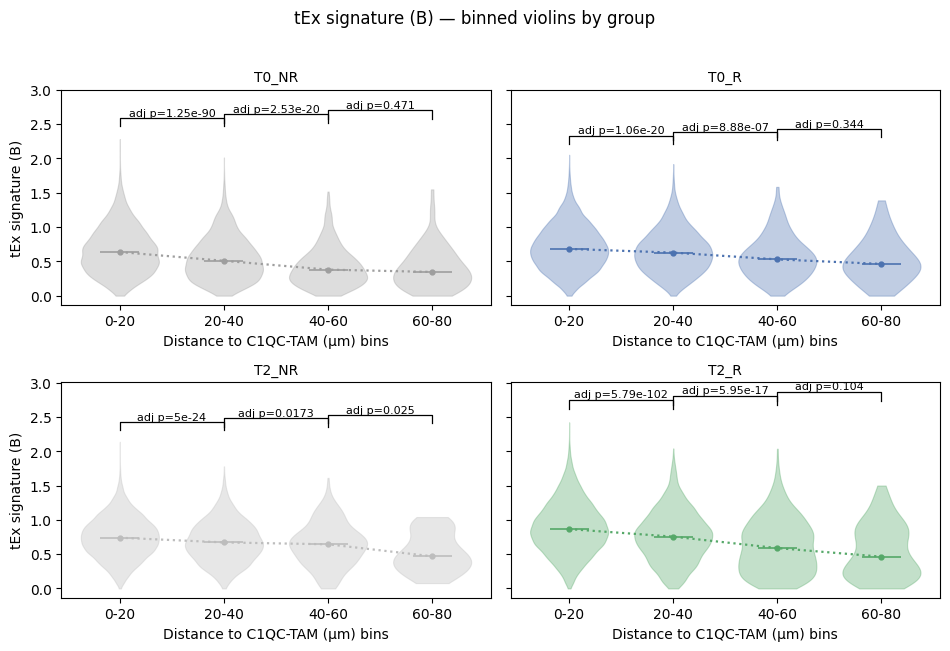

[OK] saved: outputs_distance_sig_prevstyle_20260219_203134/tEx_signature_(B)_binned_violin_by_group_prevstyle.png
[OK] stats saved: outputs_distance_sig_prevstyle_20260219_203134/tEx_signature_(B)_binned_violin_by_group_prevstyle_pairwise_wilcox.csv


In [4]:
import os
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.spatial import cKDTree
from scipy.stats import mannwhitneyu

# ----------------------------
# Gene sets
# ----------------------------
GENES_PEX = ["TCF7","LEF1","NR4A1","NR4A3","CD55","FOXP1","PDE4B","PER1","PFKFB3","REL","PIK3R1","STAT4","TC2N","USP36"]
GENES_TEX = ["HAVCR2","LAG3","PDCD1","IFNG","TIGIT","ANP32E","ANXA5","APOBEC3C","APOBEC3G","CALM3","CCNDBP1","CD27","CD38",
             "CSNK2B","CTSC","CXCR6","EID1","EIF3C","EWSR1","GBP5","GIMAP4","GZMA","GZMB","GZMH","HMGB2","HNRNPF","IDH2",
             "IFI16","IKZF3","IL2RB","INPP4B","ITM2A","KLRD1","LASP1","LAT","LCK","NONO","PARK7","PKM","PPP1CA","PRDM1",
             "PRF1","PRKAR1A","PRR13","PSMA6","PTPN6","RAB27A","RAN","RBPJ","RHOA","RPN1","SH2D1A","SIRPG","SLAMF7",
             "SNRPB","SOD1","STAT1","TAP1","TNFRSF1B","TRAF3IP3","TSPO","TUBB","U2AF1","UCP2","XRCC5","XRCC6"]

# ----------------------------
# OUTDIR: unique per run (no overwrite)
# ----------------------------
ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUTDIR = f"outputs_distance_sig_prevstyle_{ts}"
os.makedirs(OUTDIR, exist_ok=False)
print("OUTDIR =", OUTDIR)

# ----------------------------
# Settings (prev style)
# ----------------------------
UM_PER_UNIT = 1.0
DIST_MIN, DIST_MAX = 0, 80

CLUSTER_KEY = "cell_type"
SAMPLE_KEY  = "sample_name"
TIME_KEY    = "Timepoint"   # T0/T2
RESP_KEY    = "Response"    # Responder/Non-responder

T1 = "Exhausted T cell(tEx)"
T2 = "C1QC-TAM"

GROUPS_ORDER = ["T0_NR", "T0_R", "T2_NR", "T2_R"]
BOX_COLORS = {
    "T0_NR": "#9E9E9E",
    "T0_R":  "#4C72B0",
    "T2_NR": "#BDBDBD",
    "T2_R":  "#55A868",
}

def _to_dense(X):
    if sp.issparse(X):
        return X.toarray()
    return np.asarray(X)

def _bh_adjust(pvals):
    """Benjamini–Hochberg (FDR). np.nan stays np.nan."""
    pvals = np.asarray(pvals, dtype=float)
    adj = np.full_like(pvals, np.nan, dtype=float)
    mask = np.isfinite(pvals)
    if not mask.any():
        return adj

    pv = pvals[mask]
    m = pv.size
    order = np.argsort(pv)
    ranked = pv[order]
    q = ranked * m / (np.arange(1, m + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    adj_masked = np.empty_like(pv)
    adj_masked[order] = q
    adj[mask] = adj_masked
    return adj

def _make_group(tp, rp):
    tp = str(tp)
    rp = str(rp)
    if tp not in {"T0", "T2"}:
        return None
    if rp not in {"Responder", "Non-responder"}:
        return None
    return f"{tp}_{'R' if rp=='Responder' else 'NR'}"

# ============================================================
# 1) Signature calculation (mean) on adata (same formula as before)
# ============================================================
vn = pd.Index(adata.var_names)
A = [g for g in GENES_PEX if g in vn]
B = [g for g in GENES_TEX if g in vn]

if len(A) > 0:
    XA = _to_dense(adata[:, A].X)
    A_score_all = np.nanmean(XA, axis=1).ravel()
else:
    A_score_all = np.full(adata.n_obs, np.nan, dtype=float)

if len(B) > 0:
    XB = _to_dense(adata[:, B].X)
    B_score_all = np.nanmean(XB, axis=1).ravel()
else:
    B_score_all = np.full(adata.n_obs, np.nan, dtype=float)

print(f"pEx genes used: {len(A)}/{len(GENES_PEX)}")
print(f"tEx genes used: {len(B)}/{len(GENES_TEX)}")

# ============================================================
# 2) Distance calculation (PREV STYLE): KDTree within each sample_name (core)
#    tEx -> nearest C1QC-TAM within same sample_name
# ============================================================
coords = adata.obsm["spatial"]
if coords is None or len(coords) != adata.n_obs:
    raise ValueError("adata.obsm['spatial'] must exist and match n_obs")

obs = adata.obs
is_tex = (obs[CLUSTER_KEY].astype(str) == T1).to_numpy()
is_tam = (obs[CLUSTER_KEY].astype(str) == T2).to_numpy()

dist_all = np.full(adata.n_obs, np.nan, dtype=float)

# group by core (sample_name)
samples = obs[SAMPLE_KEY].astype(str).to_numpy()
unique_samples = pd.unique(samples)

for s in unique_samples:
    idx_s = np.where(samples == s)[0]
    tex_s = idx_s[is_tex[idx_s]]
    tam_s = idx_s[is_tam[idx_s]]
    if tex_s.size == 0:
        continue
    if tam_s.size == 0:
        # no TAM in this core -> keep NaN
        continue

    tree = cKDTree(coords[tam_s])
    d, _ = tree.query(coords[tex_s], k=1)
    dist_all[tex_s] = d * UM_PER_UNIT

# ============================================================
# 3) Build df (tEx only), group label, signatures, distance
# ============================================================
tex_idx = np.where(is_tex)[0]
df = pd.DataFrame({
    "cell_index": tex_idx,
    "distance_um": dist_all[tex_idx],
    "Timepoint": obs.iloc[tex_idx][TIME_KEY].to_numpy(),
    "Response":  obs.iloc[tex_idx][RESP_KEY].to_numpy(),
})
df["group"] = [ _make_group(tp, rp) for tp, rp in zip(df["Timepoint"], df["Response"]) ]
df["sigA"] = A_score_all[tex_idx]
df["sigB"] = B_score_all[tex_idx]

# keep valid group + finite distance + finite signatures when plotting
df.to_csv(os.path.join(OUTDIR, "df_tex_prevstyle_distance_signatures.csv"), index=False)
print("[OK] saved df:", os.path.join(OUTDIR, "df_tex_prevstyle_distance_signatures.csv"))

# ============================================================
# 4) Plot + stats (same as your function)
# ============================================================
def binned_violinplot_per_group(
    sig_col,
    bins=np.array([0, 20, 40, 60, 80]),
    title_stub="",
    annotate_adjacent=True,
    save_stats=True
):
    groups = GROUPS_ORDER

    sub = df[
        df["distance_um"].between(DIST_MIN, DIST_MAX)
        & np.isfinite(df[sig_col])
        & df["group"].isin(groups)
    ].copy()

    sub["bin"] = pd.cut(sub["distance_um"], bins=bins, include_lowest=True, right=True)
    levels = sub["bin"].cat.categories
    labels = [f"{int(b.left)}-{int(b.right)}" for b in levels]
    xs = np.arange(len(levels))

    fig, axes = plt.subplots(2, 2, figsize=(9.6, 6.6), sharex=False, sharey=True)
    axes = axes.ravel()

    vals = {
        g: [sub.loc[(sub["bin"] == b) & (sub["group"] == g), sig_col].values for b in levels]
        for g in groups
    }

    rows = []

    for gi, g in enumerate(groups):
        ax = axes[gi]
        col = BOX_COLORS.get(g, "#808080")

        mask = np.array([(v.size >= 3) and (np.nanstd(v) > 0) for v in vals[g]], dtype=bool)
        if mask.any():
            data = [vals[g][i] for i in range(len(levels)) if mask[i]]
            positions = xs[mask]
            vp = ax.violinplot(
                data,
                positions=positions,
                widths=0.75,
                showmeans=False, showextrema=False, showmedians=True
            )
            for body in vp['bodies']:
                body.set_facecolor(col)
                body.set_edgecolor(col)
                body.set_alpha(0.35)
                body.set_linewidth(0.8)
            if 'cmedians' in vp:
                vp['cmedians'].set_color(col)
                vp['cmedians'].set_linewidth(1.2)

        med = [np.nan if v.size == 0 else float(np.median(v)) for v in vals[g]]
        ax.plot(xs, med, linestyle=":", linewidth=1.6, marker="o", markersize=3.5,
                color=col, zorder=3)

        ax.set_xticks(xs)
        ax.set_xticklabels(labels, rotation=0)
        ax.set_xlabel(f"Distance to {T2} (µm) bins")
        if gi % 2 == 0:
            ax.set_ylabel(title_stub)
        ax.set_title(g, fontsize=10)
        ax.grid(False)

        # stats: ALL pairs i<j (two-sided Mann–Whitney)
        for i in range(len(levels)):
            for j in range(i + 1, len(levels)):
                a, b = vals[g][i], vals[g][j]
                if (a.size < 3) or (b.size < 3):
                    p = np.nan
                else:
                    try:
                        p = mannwhitneyu(a, b, alternative='two-sided').pvalue
                    except Exception:
                        p = np.nan
                rows.append({
                    "group": g,
                    "bin1": labels[i], "bin2": labels[j],
                    "i": i, "j": j,
                    "n1": int(a.size), "n2": int(b.size),
                    "p": p
                })

    # BH across all comparisons
    if rows:
        p_vec = np.array([r["p"] for r in rows], float)
        adj = _bh_adjust(p_vec)
        for k in range(len(rows)):
            rows[k]["adj_p"] = float(adj[k]) if np.isfinite(adj[k]) else np.nan

    # annotate adjacent bins only (i vs i+1)
    if annotate_adjacent and rows:
        for gi, g in enumerate(groups):
            ax = axes[gi]
            ymax = -np.inf
            ymin = np.inf
            any_data = False
            for v in vals[g]:
                if v.size:
                    ymax = max(ymax, np.nanmax(v))
                    ymin = min(ymin, np.nanmin(v))
                    any_data = True
            if not any_data:
                continue

            ypad = (ymax - ymin) * 0.08 if np.isfinite(ymax - ymin) and (ymax > ymin) else 0.2

            def _annot(ax, x1, x2, y, text):
                h = ypad * 0.7
                ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], linewidth=0.9, color='k')
                ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom', fontsize=8)

            for i in range(len(levels) - 1):
                hit = next((r for r in rows if (r["group"] == g and r["i"] == i and r["j"] == i + 1)), None)
                if (hit is None) or (not np.isfinite(hit["adj_p"])):
                    continue
                text = f"adj p={hit['adj_p']:.3g}"
                x1, x2 = xs[i], xs[i + 1]
                y = ymax + ypad * (1.0 + 0.6 * i / max(1, len(levels) - 2))
                _annot(ax, x1, x2, y, text)

            ax.set_ylim(top=max(ax.get_ylim()[1], ymax + ypad * 3))

    fig.suptitle(f"{title_stub} — binned violins by group", fontsize=12, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    base = os.path.join(OUTDIR, f"{title_stub.replace(' ', '_')}_binned_violin_by_group_prevstyle")
    fig.savefig(base + ".png", dpi=600, bbox_inches='tight', pad_inches=0.2)
    fig.savefig(base + ".pdf", dpi=600, bbox_inches='tight', pad_inches=0.2)
    plt.show()
    print("[OK] saved:", base + ".png")

    if save_stats and rows:
        out = pd.DataFrame(rows)
        out_path = base + "_pairwise_wilcox.csv"
        out.to_csv(out_path, index=False)
        print("[OK] stats saved:", out_path)

# Run
binned_violinplot_per_group("sigA", title_stub="pEx signature (A)")
binned_violinplot_per_group("sigB", title_stub="tEx signature (B)")



In [36]:
adata.obs.iloc[df["cell_index"].to_numpy(), :]["cell_type"].value_counts()


cell_type
Exhausted T cell(tEx)                 99985
B cell                                    0
C1QC-TAM                                  0
CCL3-TAM                                  0
ABCA1-TAM                                 0
CD56-high-NK                              0
CD56-low-NK                               0
Cancer cell                               0
CD8-STR                                   0
EndMT                                     0
Endothelial                               0
Fibroblast                                0
GPNMB-TAM                                 0
ILC                                       0
Intermediate exhausted T cell(iEx)        0
Mast cell                                 0
Monocyte                                  0
Naive T cell                              0
Plasma cell                               0
Progenitor exhausted T cell(pEx)          0
Prolif-TAM                                0
Proliferative T cell                      0
Temra                 

In [5]:
NEAR_UM = 20

df["near_tam"] = np.isfinite(df["distance_um"]) & (df["distance_um"] <= NEAR_UM)
df_near = df[df["near_tam"]].copy()
print("tEx within 20um:", df_near.shape[0], "/", df.shape[0])

tEx within 20um: 79705 / 99985


In [6]:
from scipy.stats import mannwhitneyu

def compare_R_vs_NR_within_timepoint(df_in, sig_col):
    rows = []
    for tp in ["T0", "T2"]:
        sub = df_in[(df_in["Timepoint"].astype(str) == tp) & np.isfinite(df_in[sig_col])].copy()

        r  = sub[sub["Response"].astype(str) == "Responder"][sig_col].values
        nr = sub[sub["Response"].astype(str) == "Non-responder"][sig_col].values

        if (r.size < 3) or (nr.size < 3):
            p = np.nan
        else:
            p = mannwhitneyu(r, nr, alternative="two-sided").pvalue

        rows.append({
            "Timepoint": tp,
            "sig": sig_col,
            "n_R": int(r.size),
            "n_NR": int(nr.size),
            "p": p,
            "median_R": float(np.median(r)) if r.size else np.nan,
            "median_NR": float(np.median(nr)) if nr.size else np.nan,
        })

    out = pd.DataFrame(rows)
    out["adj_p"] = _bh_adjust(out["p"].values)
    return out

stats_A = compare_R_vs_NR_within_timepoint(df_near, "sigA")
stats_B = compare_R_vs_NR_within_timepoint(df_near, "sigB")

stats_A.to_csv(os.path.join(OUTDIR, "stats_R_vs_NR_TP_sigA_within20um.csv"), index=False)
stats_B.to_csv(os.path.join(OUTDIR, "stats_R_vs_NR_TP_sigB_within20um.csv"), index=False)

print(stats_A)
print(stats_B)

  Timepoint   sig    n_R   n_NR             p  median_R  median_NR  \
0        T0  sigA  19160  13846  1.196288e-01   0.00000        0.0   
1        T2  sigA  28011  18688  1.076707e-89   0.23003        0.0   

          adj_p  
0  1.196288e-01  
1  2.153413e-89  
  Timepoint   sig    n_R   n_NR             p  median_R  median_NR  \
0        T0  sigB  19160  13846  1.232125e-29  0.681105   0.635689   
1        T2  sigB  28011  18688  0.000000e+00  0.865177   0.739698   

          adj_p  
0  1.232125e-29  
1  0.000000e+00  


In [7]:
def compare_R_vs_NR_by_bin_within_timepoint(df_in, sig_col, bins=np.array([0,20,40,60,80])):
    sub = df_in[
        np.isfinite(df_in["distance_um"]) &
        np.isfinite(df_in[sig_col]) &
        df_in["distance_um"].between(DIST_MIN, DIST_MAX)
    ].copy()

    sub["bin"] = pd.cut(sub["distance_um"], bins=bins, include_lowest=True, right=True)
    levels = sub["bin"].cat.categories
    labels = [f"{int(b.left)}-{int(b.right)}" for b in levels]

    rows = []
    for tp in ["T0", "T2"]:
        for bi, b in enumerate(levels):
            s = sub[(sub["Timepoint"].astype(str)==tp) & (sub["bin"]==b)]

            r  = s[s["Response"].astype(str)=="Responder"][sig_col].values
            nr = s[s["Response"].astype(str)=="Non-responder"][sig_col].values

            if (r.size < 3) or (nr.size < 3):
                p = np.nan
            else:
                p = mannwhitneyu(r, nr, alternative="two-sided").pvalue

            rows.append({
                "Timepoint": tp,
                "bin": labels[bi],
                "sig": sig_col,
                "n_R": int(r.size),
                "n_NR": int(nr.size),
                "p": p,
                "median_R": float(np.median(r)) if r.size else np.nan,
                "median_NR": float(np.median(nr)) if nr.size else np.nan,
            })

    out = pd.DataFrame(rows)
    out["adj_p"] = _bh_adjust(out["p"].values)  
    return out

statsA_bins = compare_R_vs_NR_by_bin_within_timepoint(df, "sigA")  
statsB_bins = compare_R_vs_NR_by_bin_within_timepoint(df, "sigB")

statsA_bins.to_csv(os.path.join(OUTDIR, "stats_R_vs_NR_TP_bybin_sigA.csv"), index=False)
statsB_bins.to_csv(os.path.join(OUTDIR, "stats_R_vs_NR_TP_bybin_sigB.csv"), index=False)

/tmp/kyutae/32067986/c151606.ll.unc.edu/ipykernel_2216206/1749644333.py:226: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


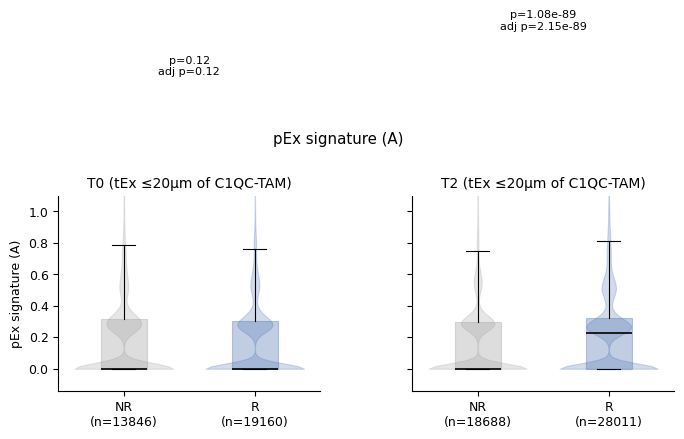

[OK] saved: outputs_distance_sig_prevstyle_20260219_203134/PUB_pEx_signature_(A)_RvsNR_within20um.pdf
[OK] saved: outputs_distance_sig_prevstyle_20260219_203134/PUB_pEx_signature_(A)_RvsNR_within20um.png
[OK] stats: outputs_distance_sig_prevstyle_20260219_203134/PUB_pEx_signature_(A)_RvsNR_within20um_stats.csv


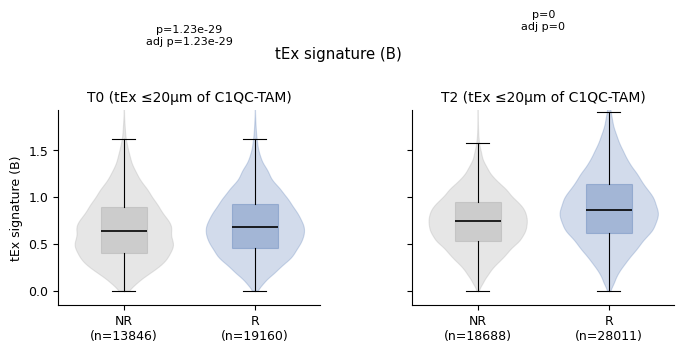

[OK] saved: outputs_distance_sig_prevstyle_20260219_203134/PUB_tEx_signature_(B)_RvsNR_within20um.pdf
[OK] saved: outputs_distance_sig_prevstyle_20260219_203134/PUB_tEx_signature_(B)_RvsNR_within20um.png
[OK] stats: outputs_distance_sig_prevstyle_20260219_203134/PUB_tEx_signature_(B)_RvsNR_within20um_stats.csv


In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ----------------------------
# helpers
# ----------------------------
def _mw_p(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[np.isfinite(a)]
    b = b[np.isfinite(b)]
    if (a.size < 3) or (b.size < 3):
        return np.nan
    try:
        return mannwhitneyu(a, b, alternative="two-sided").pvalue
    except Exception:
        return np.nan

def _format_p(p):
    if not np.isfinite(p):
        return "p=n/a"
    return f"p={p:.3g}"

def _bh_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    adj = np.full_like(pvals, np.nan, dtype=float)
    mask = np.isfinite(pvals)
    if not mask.any():
        return adj
    pv = pvals[mask]
    m = pv.size
    order = np.argsort(pv)
    ranked = pv[order]
    q = ranked * m / (np.arange(1, m + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)
    adj_masked = np.empty_like(pv)
    adj_masked[order] = q
    adj[mask] = adj_masked
    return adj

# ----------------------------
# publication plot
# ----------------------------
def plot_pub_R_vs_NR_within20um(
    df,
    sig_col,
    outdir,
    near_um=20,
    timepoints=("T0", "T2"),
    figsize=(7.0, 3.2),
    dpi=600,
    title=None,
    colors=("Responder", "Non-responder"),
    palette=None,
    show_points=True,
    point_size=0,
    seed=0,
):
    """
    Publication-quality: two panels (T0, T2), each compares Responder vs Non-responder
    using only tEx within <= near_um of C1QC-TAM.
    Saves PDF + PNG, and stats CSV (MWU p and BH-adjusted across timepoints).
    """
    rng = np.random.default_rng(seed)

    if palette is None:
        # color-blind friendly-ish defaults
        palette = {
            "Responder": "#4C72B0",
            "Non-responder": "#9E9E9E",
        }

    d0 = df.copy()
    d0 = d0[np.isfinite(d0["distance_um"]) & (d0["distance_um"] <= near_um)]
    d0 = d0[d0["Timepoint"].astype(str).isin(list(timepoints))]
    d0 = d0[d0["Response"].astype(str).isin(["Responder", "Non-responder"])]
    d0 = d0[np.isfinite(d0[sig_col])].copy()

    # stats per timepoint
    stat_rows = []
    for tp in timepoints:
        sub = d0[d0["Timepoint"].astype(str) == tp]
        a = sub[sub["Response"].astype(str) == "Responder"][sig_col].values
        b = sub[sub["Response"].astype(str) == "Non-responder"][sig_col].values
        p = _mw_p(a, b)
        stat_rows.append({
            "Timepoint": tp,
            "sig": sig_col,
            "near_um": near_um,
            "n_R": int(np.isfinite(a).sum()),
            "n_NR": int(np.isfinite(b).sum()),
            "median_R": float(np.median(a)) if a.size else np.nan,
            "median_NR": float(np.median(b)) if b.size else np.nan,
            "p": p,
        })
    stats = pd.DataFrame(stat_rows)
    stats["adj_p"] = _bh_adjust(stats["p"].values)

    # plotting style (paper-friendly)
    plt.rcParams.update({
        "pdf.fonttype": 42,          # editable text in Illustrator
        "ps.fonttype": 42,
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.linewidth": 0.8,
    })

    fig, axes = plt.subplots(1, len(timepoints), figsize=figsize, sharey=True)
    if len(timepoints) == 1:
        axes = [axes]

    # y-limits (robust): use 1–99% to avoid a single outlier blowing scale
    y = d0[sig_col].to_numpy()
    if y.size:
        ylo = np.nanpercentile(y, 1)
        yhi = np.nanpercentile(y, 99)
        if np.isfinite(ylo) and np.isfinite(yhi) and (yhi > ylo):
            pad = (yhi - ylo) * 0.15
            ylim = (ylo - pad, yhi + pad)
        else:
            ylim = None
    else:
        ylim = None

    for ax, tp in zip(axes, timepoints):
        sub = d0[d0["Timepoint"].astype(str) == tp].copy()

        order = ["Non-responder", "Responder"]  # NR left, R right
        x_positions = np.arange(len(order))

        # violin + box
        data = [sub[sub["Response"].astype(str) == g][sig_col].values for g in order]

        # violin
        vp = ax.violinplot(
            data,
            positions=x_positions,
            widths=0.75,
            showmeans=False,
            showextrema=False,
            showmedians=False
        )
        for body, g in zip(vp["bodies"], order):
            body.set_facecolor(palette.get(g, "#808080"))
            body.set_edgecolor(palette.get(g, "#808080"))
            body.set_alpha(0.25)
            body.set_linewidth(0.8)

        # box
        bp = ax.boxplot(
            data,
            positions=x_positions,
            widths=0.35,
            patch_artist=True,
            showfliers=False,
            medianprops={"linewidth": 1.2, "color": "k"},
            boxprops={"linewidth": 0.8},
            whiskerprops={"linewidth": 0.8},
            capprops={"linewidth": 0.8},
        )
        for patch, g in zip(bp["boxes"], order):
            patch.set_facecolor(palette.get(g, "#808080"))
            patch.set_alpha(0.35)
            patch.set_edgecolor(palette.get(g, "#808080"))

        # points (jitter)
        if show_points:
            for xi, g in zip(x_positions, order):
                vals = sub[sub["Response"].astype(str) == g][sig_col].values
                vals = vals[np.isfinite(vals)]
                if vals.size == 0:
                    continue
                jitter = rng.normal(0, 0.06, size=vals.size)
                ax.scatter(
                    np.full(vals.size, xi) + jitter,
                    vals,
                    s=point_size,
                    alpha=0.55,
                    linewidths=0,
                    color=palette.get(g, "#808080"),
                    zorder=3
                )

        # x labels + title
        n_nr = int(np.isfinite(data[0]).sum())
        n_r  = int(np.isfinite(data[1]).sum())
        ax.set_xticks(x_positions)
        ax.set_xticklabels([f"NR\n(n={n_nr})", f"R\n(n={n_r})"])
        ax.set_title(f"{tp} (tEx ≤{near_um}µm of {T2})")

        ax.grid(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # p-value annotation (use BH-adjusted across timepoints)
        st = stats[stats["Timepoint"] == tp].iloc[0]
        p_txt = _format_p(st["p"])
        adj_txt = "adj " + _format_p(st["adj_p"]).replace("p=", "p=") if np.isfinite(st["adj_p"]) else "adj p=n/a"
        # bracket
        if (n_nr >= 3) and (n_r >= 3):
            y_max = np.nanmax(np.concatenate([data[0], data[1]]))
            y_min = np.nanmin(np.concatenate([data[0], data[1]]))
            ypad = (y_max - y_min) * 0.10 if (np.isfinite(y_max - y_min) and y_max > y_min) else 0.2
            yb = y_max + ypad
            ax.plot([x_positions[0], x_positions[0], x_positions[1], x_positions[1]],
                    [yb, yb + ypad*0.4, yb + ypad*0.4, yb],
                    color="k", linewidth=0.9)
            ax.text(np.mean(x_positions), yb + ypad*0.45, f"{p_txt}\n{adj_txt}",
                    ha="center", va="bottom", fontsize=8)

    if ylim is not None:
        for ax in axes:
            ax.set_ylim(*ylim)

    ylabel = title if title is not None else sig_col
    axes[0].set_ylabel(ylabel)

    fig.suptitle(title if title else f"{sig_col}: R vs NR within each timepoint (tEx ≤{near_um}µm)", y=1.03)
    plt.tight_layout()

    safe = (title if title else sig_col).replace(" ", "_").replace("/", "_")
    base = os.path.join(outdir, f"PUB_{safe}_RvsNR_within{near_um}um")
    fig.subplots_adjust(left=0.10, right=0.98, bottom=0.22, top=0.83, wspace=0.35)
    fig.savefig(base + ".pdf")                      # 벡터 PDF
    fig.savefig(base + ".png", dpi=dpi)            # 래스터 PNG
    plt.show()

    stats.to_csv(base + "_stats.csv", index=False)
    print("[OK] saved:", base + ".pdf")
    print("[OK] saved:", base + ".png")
    print("[OK] stats:", base + "_stats.csv")

    return stats

# ----------------------------
# run for your two signatures
# ----------------------------
NEAR_UM = 20

stats_sigA = plot_pub_R_vs_NR_within20um(
    df=df,
    sig_col="sigA",
    outdir=OUTDIR,
    near_um=NEAR_UM,
    title="pEx signature (A)",
                                        show_points=False
    
)

stats_sigB = plot_pub_R_vs_NR_within20um(
    df=df,
    sig_col="sigB",
    outdir=OUTDIR,
    near_um=NEAR_UM,
    title="tEx signature (B)",
                                        show_points=False
)

In [2]:
# === Core-wise stlearn gridding (tutorial-style) & save only ===
import os, numpy as np, pandas as pd
import scanpy as sc
import stlearn as st

# ---------------- Settings ----------------
ADATA_PATH = "combined_1103_with_cell_type.h5ad"      # Replace with your file path if needed
CORE_COL   = "sample_name"                            # Column used to identify each core
N_GRID     = 50                                       # Tutorial value: 125 x 125 ≈ 15,625 spots
OUTDIR     = "corewise_grids"                         # Output folder for saved grids
os.makedirs(OUTDIR, exist_ok=True)

LABEL_CANDIDATES = ["cell_type"]

X_KEYS = ["imagecol","x","x_um","X","X_um","pxl_col_in_fullres_um","x_location","Cell_X","centroid_x"]
Y_KEYS = ["imagerow","y","y_um","Y","Y_um","pxl_row_in_fullres_um","y_location","Cell_Y","centroid_y"]

def _pick_fuzzy(cols, candidates, what):
    norm = {str(c).strip().lower(): c for c in cols}
    for k in candidates:
        if k.lower() in norm:
            return norm[k.lower()]
    raise KeyError(f"{what} not found; tried={candidates} | available(head)={list(cols)[:10]}")

def _auto_xy(ad):
    if "spatial" in ad.obsm and ad.obsm["spatial"] is not None and ad.obsm["spatial"].shape[1] >= 2:
        XY = ad.obsm["spatial"]
        return XY[:,0].astype(float), XY[:,1].astype(float)
    xk = _pick_fuzzy(ad.obs.columns, X_KEYS, "x")
    yk = _pick_fuzzy(ad.obs.columns, Y_KEYS, "y")
    return ad.obs[xk].astype(float).to_numpy(), ad.obs[yk].astype(float).to_numpy()

def _ensure_minimal_spatial(ad, library_id):
    # stlearn copies ad.uns['spatial'] when generating grids, so ensure the minimal structure exists
    if "spatial" not in ad.uns:
        ad.uns["spatial"] = {}
    if library_id not in ad.uns["spatial"]:
        ad.uns["spatial"][library_id] = {"images": {}, "scalefactors": {}, "metadata": {}}
    ad.uns["spatial"][library_id]["scalefactors"].setdefault("spot_diameter_fullres", 1.0)

def _choose_label_key(ad):
    for k in LABEL_CANDIDATES:
        if k in ad.obs:
            return k
    raise KeyError(f"No valid use_label key found. Candidates={LABEL_CANDIDATES} | ad.obs cols(head)={list(ad.obs.columns)[:12]}")

def grid_one_core(ad_core, core_id):
    # Set coordinates
    x, y = _auto_xy(ad_core)
    ad = ad_core.copy()
    ad.obsm["spatial"] = np.column_stack([x, y])

    # Ensure minimal spatial metadata (required for grid generation)
    _ensure_minimal_spatial(ad, library_id=str(core_id))

    # Normalize library size as in the tutorial (only on the core copy; original remains unchanged)
    sc.pp.normalize_total(ad, target_sum=1e4, inplace=True)

    # Select use_label
    use_label = _choose_label_key(ad)

    # Gridding
    print(f"Gridding... core={core_id} | n_row=n_col={N_GRID} | use_label={use_label}")
    grid = st.tl.cci.grid(ad, n_row=N_GRID, n_col=N_GRID, use_label=use_label)
    print(" -> grid.shape =", grid.shape)  # e.g. (14364, n_genes)

    # Save
    outpath = os.path.join(OUTDIR, f"grid_{core_id}.h5ad")
    grid.write(outpath)
    return outpath, grid.n_obs, grid.n_vars, use_label

# ---------------- Run ----------------
adata = sc.read_h5ad(ADATA_PATH)
if CORE_COL not in adata.obs:
    raise KeyError(f"adata.obs['{CORE_COL}'] is required.")

summary = []
for core_id, idx in adata.obs.groupby(CORE_COL).groups.items():
    ad_core = adata[idx].copy()
    try:
        outpath, n_spots, n_vars, label_key = grid_one_core(ad_core, core_id)
        summary.append({
            "core": str(core_id),
            "grid_file": outpath,
            "grid_spots": n_spots,
            "grid_vars": n_vars,
            "use_label": label_key
        })
    except Exception as e:
        print(f"[ERROR] core={core_id} failed: {e}")
        summary.append({
            "core": str(core_id),
            "grid_file": "",
            "grid_spots": 0,
            "grid_vars": 0,
            "use_label": "",
            "error": str(e)
        })

# Save summary
pd.DataFrame(summary).to_csv(os.path.join(OUTDIR, "grid_summary.csv"), index=False)
print(f"[OK] Saved successfully → {OUTDIR}/grid_<core>.h5ad, grid_summary.csv")


/tmp/kyutae/35672519/c1516ood14.ll.unc.edu/ipykernel_1384235/4128903294.py:78: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for core_id, idx in adata.obs.groupby(CORE_COL).groups.items():


Gridding... core=POST_T1 | n_row=n_col=50 | use_label=cell_type
Gridding...
 -> grid.shape = (1701, 5001)
Gridding... core=POST_T2 | n_row=n_col=50 | use_label=cell_type
Gridding...
 -> grid.shape = (1490, 5001)
Gridding... core=POST_T3 | n_row=n_col=50 | use_label=cell_type
Gridding...
 -> grid.shape = (1572, 5001)
Gridding... core=POST_T4 | n_row=n_col=50 | use_label=cell_type
Gridding...
 -> grid.shape = (1899, 5001)
Gridding... core=POST_T5 | n_row=n_col=50 | use_label=cell_type
Gridding...
 -> grid.shape = (1861, 5001)
Gridding... core=POST_T6 | n_row=n_col=50 | use_label=cell_type
Gridding...
 -> grid.shape = (2020, 5001)
Gridding... core=POST_T7 | n_row=n_col=50 | use_label=cell_type
Gridding...
 -> grid.shape = (1628, 5001)
Gridding... core=POST_T8 | n_row=n_col=50 | use_label=cell_type
Gridding...
 -> grid.shape = (1876, 5001)
Gridding... core=POST_T9 | n_row=n_col=50 | use_label=cell_type
Gridding...
 -> grid.shape = (1975, 5001)
Gridding... core=POST_T10 | n_row=n_col=50 | u

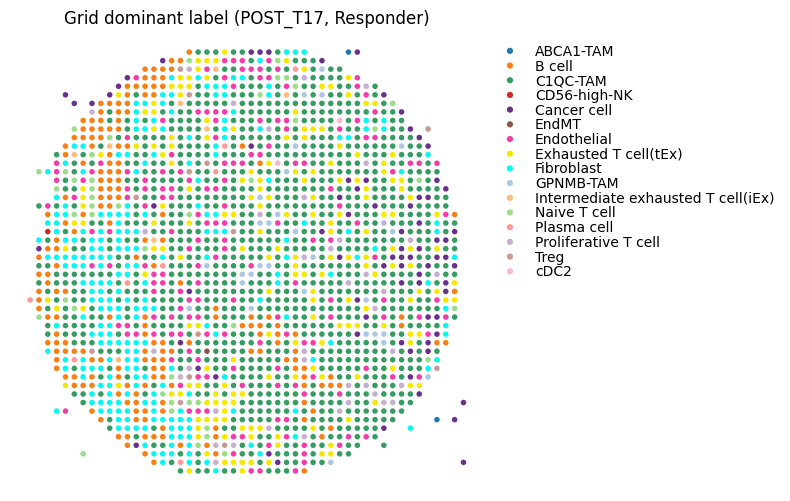

<Figure size 640x480 with 0 Axes>

In [3]:
import scanpy as sc
import stlearn as st
import matplotlib.pyplot as plt

SAMPLE_ID = "POST_T17"  
GRID_FILE = f"corewise_grids/grid_{SAMPLE_ID}.h5ad"
CLUSTER_KEY = "cell_type"

grid = sc.read_h5ad(GRID_FILE)

fig, ax = plt.subplots(figsize=(8, 8))
st.pl.cluster_plot(
    grid,
    use_label=CLUSTER_KEY,
    size=16,
    show_image=False,
    show_plot=False,
    ax=ax
)
ax.set_aspect('equal')
ax.set_title(f"Grid dominant label ({SAMPLE_ID}, Responder)")
plt.tight_layout()
plt.savefig(f"grid_{SAMPLE_ID}_cluster.pdf")
plt.savefig(f"grid_{SAMPLE_ID}_cluster.png", dpi=300)
plt.show()

ax.set_aspect('equal')
ax.set_title(f"Grid dominant label ({SAMPLE_ID}, Responder)")
plt.tight_layout()
plt.savefig(f"grid_{SAMPLE_ID}_gene.pdf")
plt.savefig(f"grid_{SAMPLE_ID}_gene.png", dpi=300)
plt.show()



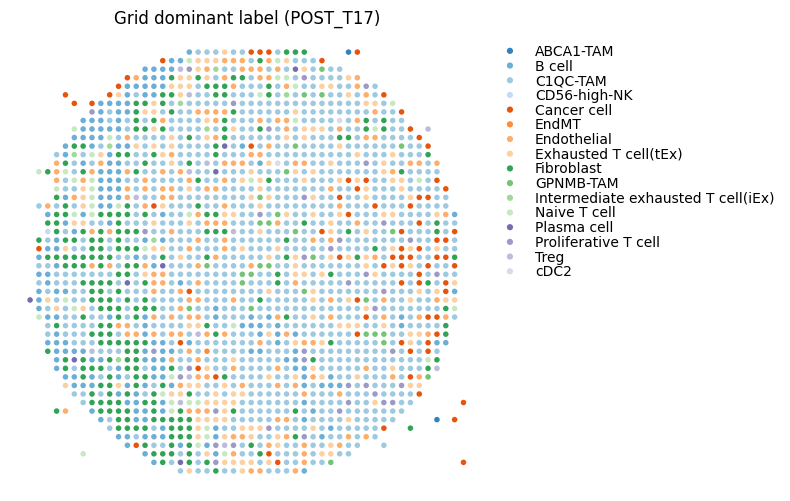

Index(['ABCA1-TAM', 'B cell', 'C1QC-TAM', 'CD56-high-NK', 'Cancer cell',
       'EndMT', 'Endothelial', 'Exhausted T cell(tEx)', 'Fibroblast',
       'GPNMB-TAM', 'Intermediate exhausted T cell(iEx)', 'Naive T cell',
       'Plasma cell', 'Proliferative T cell', 'Treg', 'cDC2'],
      dtype='object')
['#3182bd', '#6baed6', '#9ecae1', '#c6dbef', '#e6550d', '#fd8d3c', '#fdae6b', '#fdd0a2', '#31a354', '#74c476', '#a1d99b', '#c7e9c0', '#756bb1', '#9e9ac8', '#bcbddc', '#dadaeb']
16
['ABCA1-TAM', 'B cell', 'C1QC-TAM', 'CD56-high-NK', 'Cancer cell', 'EndMT', 'Endothelial', 'Exhausted T cell(tEx)', 'Fibroblast', 'GPNMB-TAM', 'Intermediate exhausted T cell(iEx)', 'Naive T cell', 'Plasma cell', 'Proliferative T cell', 'Treg', 'cDC2']


In [4]:
import scanpy as sc
import stlearn as st
import matplotlib.pyplot as plt

SAMPLE_ID = "POST_T17"
GRID_FILE = f"corewise_grids/grid_{SAMPLE_ID}.h5ad"
CLUSTER_KEY = "cell_type"


fig, ax = plt.subplots(figsize=(8, 8))
st.pl.cluster_plot(
    grid,
    use_label=CLUSTER_KEY,
        cmap= "tab20c",
    size=16,
    show_image=False,
    show_plot=False,
    ax=ax
)
ax.set_aspect('equal')
ax.set_title(f"Grid dominant label ({SAMPLE_ID})", fontsize=12)
plt.tight_layout()
plt.savefig(f"grid_{SAMPLE_ID}_cluster_fixedcolor.pdf")
plt.savefig(f"grid_{SAMPLE_ID}_cluster_fixedcolor.png", dpi=300)
plt.show()

cats = grid.obs[CLUSTER_KEY].astype("category").cat.categories
print(cats)
print(grid.uns.get(f"{CLUSTER_KEY}_colors"))
print(len(grid.uns.get(f"{CLUSTER_KEY}_colors", [])))
print(grid.obs[CLUSTER_KEY].cat.categories.tolist())


[computed] {'pEx_used_genes': 14, 'tEx_used_genes': 66}


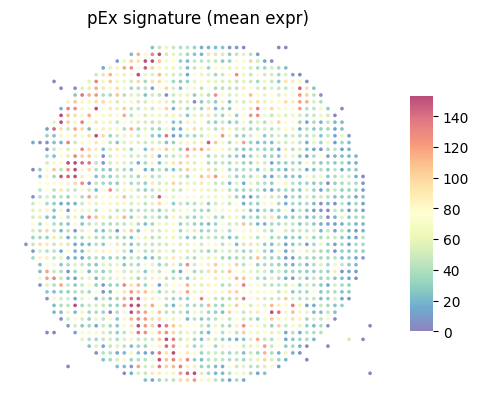

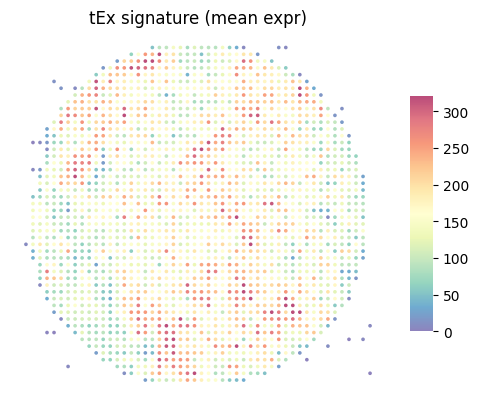

In [5]:
import numpy as np, pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
import stlearn as st

GENES_PEX = ["TCF7","LEF1","NR4A1","NR4A3","CD55","FOXP1","PDE4B","PER1","PFKFB3","REL","PIK3R1","STAT4","TC2N","USP36"]
GENES_TEX = ["HAVCR2","LAG3","PDCD1","IFNG","TIGIT","ANP32E","ANXA5","APOBEC3C","APOBEC3G","CALM3","CCNDBP1","CD27","CD38","CSNK2B",
             "CTSC","CXCR6","EID1","EIF3C","EWSR1","GBP5","GIMAP4","GZMA","GZMB","GZMH","HMGB2","HNRNPF","IDH2","IFI16","IKZF3",
             "IL2RB","INPP4B","ITM2A","KLRD1","LASP1","LAT","LCK","NONO","PARK7","PKM","PPP1CA","PRDM1","PRF1","PRKAR1A","PRR13",
             "PSMA6","PTPN6","RAB27A","RAN","RBPJ","RHOA","RPN1","SH2D1A","SIRPG","SLAMF7","SNRPB","SOD1","STAT1","TAP1",
             "TNFRSF1B","TRAF3IP3","TSPO","TUBB","U2AF1","UCP2","XRCC5","XRCC6"]

def _present_genes_case_insensitive(ad, genes):
    var_upper = pd.Series(ad.var_names, index=pd.Index([v.upper() for v in ad.var_names]))
    want = [g.upper() for g in genes]
    inter = [g for g in want if g in var_upper.index]
    return list(var_upper.loc[inter].values) 
def _signature_mean(ad, genes):
    present = _present_genes_case_insensitive(ad, genes)
    if len(present) == 0:
        return np.full(ad.n_obs, np.nan), present
    X = ad[:, present].X
    if sparse.issparse(X):
        X = X.A
    return np.nanmean(np.asarray(X), axis=1).ravel(), present

def ensure_signatures_in_obs(ad):
    added = {}
    if "pEx_score" not in ad.obs:
        s, used = _signature_mean(ad, GENES_PEX)
        ad.obs["pEx_score"] = s
        added["pEx_used_genes"] = len(used)
    if "tEx_score" not in ad.obs:
        s, used = _signature_mean(ad, GENES_TEX)
        ad.obs["tEx_score"] = s
        added["tEx_used_genes"] = len(used)
    return added

info = ensure_signatures_in_obs(grid)
if info:
    print("[computed]", info)
else:
    print("[ok] signatures already present in grid.obs")


v = grid.obs["pEx_score"].to_numpy()
vmax = np.nanpercentile(v, 99)
fig, ax = plt.subplots(figsize=(5,5))
st.pl.feat_plot(grid, feature="pEx_score", show_color_bar=True, show_plot=False, show_image=False, ax=ax, vmax=vmax)
ax.set_aspect('equal')
ax.set_title("pEx signature (mean expr)")
plt.tight_layout()
plt.savefig("grid_pEx_signature.pdf"); plt.savefig("grid_pEx_signature.png", dpi=300)
plt.show()

v = grid.obs["tEx_score"].to_numpy()
vmax = np.nanpercentile(v, 99)
fig, ax = plt.subplots(figsize=(5,5))
st.pl.feat_plot(grid, feature="tEx_score", show_color_bar=True, show_plot=False, show_image=False, ax=ax, vmax=vmax)
ax.set_aspect('equal')
ax.set_title("tEx signature (mean expr)")
plt.tight_layout()
plt.savefig("grid_tEx_signature.pdf"); plt.savefig("grid_tEx_signature.png", dpi=300)
plt.show()


In [6]:
import sys
print(sys.version)
import scanpy as sc
import stlearn as st
import matplotlib
import pandas as pd
import numpy as np

print("Python:", __import__("sys").version)
print("scanpy:", sc.__version__)
print("stlearn:", st.__version__)
print("matplotlib:", matplotlib.__version__)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)


3.10.9 (main, Mar  1 2023, 18:23:06) [GCC 11.2.0]
Python: 3.10.9 (main, Mar  1 2023, 18:23:06) [GCC 11.2.0]
scanpy: 1.10.4
stlearn: 1.1.1
matplotlib: 3.8.4
pandas: 2.3.0
numpy: 1.26.4
